# Setup env

In [ ]:
import os
import cv2
import glob
import PIL
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage import data
from skimage.util import montage 
import skimage.transform as skTrans
from skimage.transform import rotate
from skimage.transform import resize
from PIL import Image, ImageOps  


# neural imaging
import nilearn as nl
import nibabel as nib
import nilearn.plotting as nlplt


# ml libs
import keras
import keras.backend as K
import tensorflow as tf
from tensorflow.keras.utils import plot_model
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import *
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import *
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

# Image data descriptions

All BraTS multimodal scans are available as  NIfTI files (.nii.gz) -> commonly used medical imaging format to store brain imagin data obtained using MRI and describe different MRI settings 
1. **T1**: T1-weighted, native image, sagittal or axial 2D acquisitions, with 1–6 mm slice thickness.
2. **T1c**: T1-weighted, contrast-enhanced (Gadolinium) image, with 3D acquisition and 1 mm isotropic voxel size for most patients.
3. **T2**: T2-weighted image, axial 2D acquisition, with 2–6 mm slice thickness.
4. **FLAIR**: T2-weighted FLAIR image, axial, coronal, or sagittal 2D acquisitions, 2–6 mm slice thickness.

Data were acquired with different clinical protocols and various scanners from multiple (n=19) institutions.

All the imaging datasets have been segmented manually, by one to four raters, following the same annotation protocol, and their annotations were approved by experienced neuro-radiologists. Annotations comprise the GD-enhancing tumor (ET — label 4), the peritumoral edema (ED — label 2), and the necrotic and non-enhancing tumor core (NCR/NET — label 1), as described both in the BraTS 2012-2013 TMI paper and in the latest BraTS summarizing paper. The provided data are distributed after their pre-processing, i.e., co-registered to the same anatomical template, interpolated to the same resolution (1 mm^3) and skull-stripped.



**This notebook now loads the MU-Glioma-Post dataset.** Modality file suffixes map onto the BraTS names above as: `t2f` = FLAIR, `t1c` = T1c (contrast-enhanced), `t1n` = T1, `t2w` = T2, `tumorMask` = segmentation (labels 0/1/2/3, same scheme as BraTS `seg`).

In [ ]:
DATASET_PATH = './PKG - MU-Glioma-Post/MU-Glioma-Post/'

sample_dir = DATASET_PATH + 'PatientID_0003/Timepoint_1'
sample_id = 'PatientID_0003_Timepoint_1'

test_image_flair=nib.load(f'{sample_dir}/{sample_id}_brain_t2f.nii.gz').get_fdata()
test_image_t1=nib.load(f'{sample_dir}/{sample_id}_brain_t1n.nii.gz').get_fdata()
test_image_t1ce=nib.load(f'{sample_dir}/{sample_id}_brain_t1c.nii.gz').get_fdata()
test_image_t2=nib.load(f'{sample_dir}/{sample_id}_brain_t2w.nii.gz').get_fdata()
test_mask=nib.load(f'{sample_dir}/{sample_id}_tumorMask.nii.gz').get_fdata()


fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1,5, figsize = (20, 10))
slice_w = 25
ax1.imshow(test_image_flair[:,:,test_image_flair.shape[0]//2-slice_w], cmap = 'gray')
ax1.set_title('Image flair (t2f)')
ax2.imshow(test_image_t1[:,:,test_image_t1.shape[0]//2-slice_w], cmap = 'gray')
ax2.set_title('Image t1 (t1n)')
ax3.imshow(test_image_t1ce[:,:,test_image_t1ce.shape[0]//2-slice_w], cmap = 'gray')
ax3.set_title('Image t1ce (t1c)')
ax4.imshow(test_image_t2[:,:,test_image_t2.shape[0]//2-slice_w], cmap = 'gray')
ax4.set_title('Image t2 (t2w)')
ax5.imshow(test_mask[:,:,test_mask.shape[0]//2-slice_w])
ax5.set_title('Mask')

**Show whole nifti data -> print each slice from 3d data**

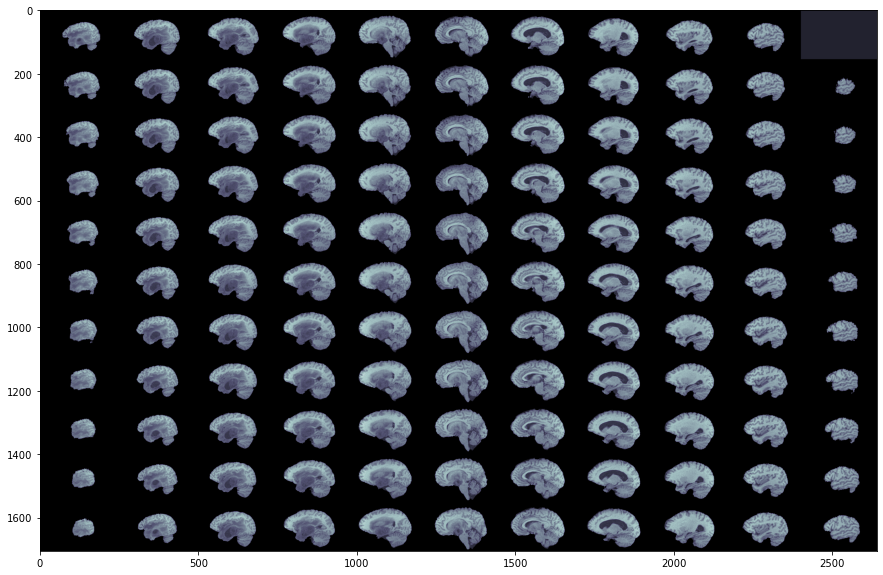

In [ ]:
# Skip 60:-60 slices since there is not much to see
fig, ax1 = plt.subplots(1, 1, figsize = (15,15))
ax1.imshow(rotate(montage(test_image_t1[60:-60,:,:]), 90, resize=True), cmap ='bone')

**Show segment of tumor for each above slice**

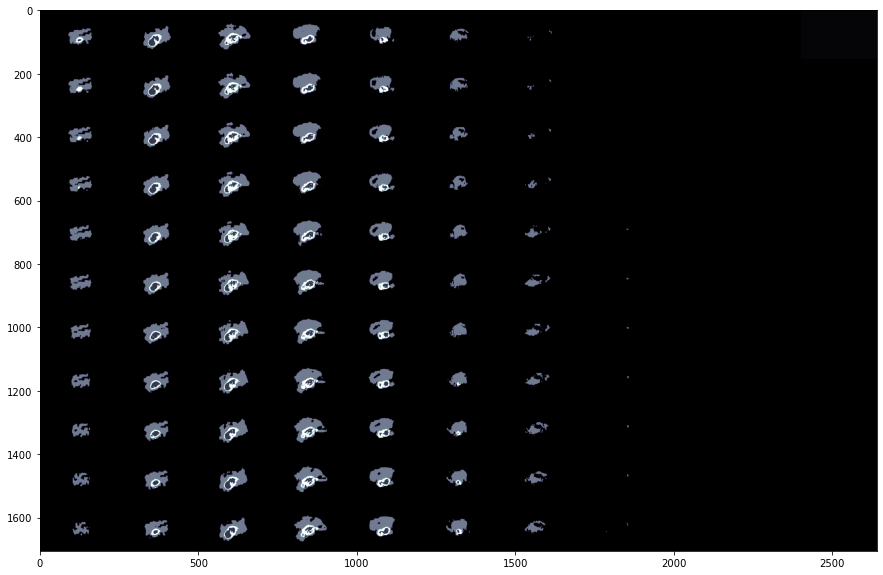

In [ ]:
# Skip 60:-60 slices since there is not much to see
fig, ax1 = plt.subplots(1, 1, figsize = (15,15))
ax1.imshow(rotate(montage(test_mask[60:-60,:,:]), 90, resize=True), cmap ='bone')

**Show segments of tumor using different effects**

In [ ]:
niimg = nl.image.load_img(f'{sample_dir}/{sample_id}_brain_t2f.nii.gz')
nimask = nl.image.load_img(f'{sample_dir}/{sample_id}_tumorMask.nii.gz')

fig, axes = plt.subplots(nrows=4, figsize=(30, 40))


nlplt.plot_anat(niimg,
                title=f'{sample_id}_brain_t2f.nii.gz plot_anat',
                axes=axes[0])

nlplt.plot_epi(niimg,
               title=f'{sample_id}_brain_t2f.nii.gz plot_epi',
               axes=axes[1])

nlplt.plot_img(niimg,
               title=f'{sample_id}_brain_t2f.nii.gz plot_img',
               axes=axes[2])

nlplt.plot_roi(nimask,
               title=f'{sample_id}_brain_t2f.nii.gz with mask plot_roi',
               bg_img=niimg,
               axes=axes[3], cmap='Paired')

plt.show()

In [ ]:
# dice loss as defined above for 4 classes
# NOTE: uses keras.ops (not keras.backend) since keras.backend's tensor-math
# functions (.flatten/.sum/.round/.clip/.abs/.square) were removed in Keras 3.
# keras.ops is the stable, backend-agnostic API going forward.
from keras import ops

def dice_coef(y_true, y_pred, smooth=1.0):
    class_num = 4
    for i in range(class_num):
        y_true_f = ops.reshape(y_true[:,:,:,i], [-1])
        y_pred_f = ops.reshape(y_pred[:,:,:,i], [-1])
        intersection = ops.sum(y_true_f * y_pred_f)
        loss = ((2. * intersection + smooth) / (ops.sum(y_true_f) + ops.sum(y_pred_f) + smooth))
        if i == 0:
            total_loss = loss
        else:
            total_loss = total_loss + loss
    total_loss = total_loss / class_num
    return total_loss

def dice_coef_loss(y_true, y_pred):
    return 1-dice_coef(y_true, y_pred)

#intersection over union
def iou(y_true, y_pred, smooth=1.0):
    intersection = ops.sum(y_true * y_pred)
    sum_ = ops.sum(y_true + y_pred)
    jac = (intersection + smooth) / (sum_ - intersection + smooth)
    return jac

# jaccard's loss
def jac_distance(y_true, y_pred):
    return - iou(y_true, y_pred)

# Computing Precision
def precision(y_true, y_pred):
        true_positives = ops.sum(ops.round(ops.clip(y_true * y_pred, 0, 1)))
        predicted_positives = ops.sum(ops.round(ops.clip(y_pred, 0, 1)))
        precision = true_positives / (predicted_positives + K.epsilon())
        return precision

# Computing Sensitivity
def sensitivity(y_true, y_pred):
    true_positives = ops.sum(ops.round(ops.clip(y_true * y_pred, 0, 1)))
    possible_positives = ops.sum(ops.round(ops.clip(y_true, 0, 1)))
    return true_positives / (possible_positives + K.epsilon())

# Computing Specificity
def specificity(y_true, y_pred):
    true_negatives = ops.sum(ops.round(ops.clip((1-y_true) * (1-y_pred), 0, 1)))
    possible_negatives = ops.sum(ops.round(ops.clip(1-y_true, 0, 1)))
    return true_negatives / (possible_negatives + K.epsilon())

def dice_coef_necrotic(y_true, y_pred, epsilon=1e-6):
    intersection = ops.sum(ops.abs(y_true[:,:,:,1] * y_pred[:,:,:,1]))
    return (2. * intersection) / (ops.sum(ops.square(y_true[:,:,:,1])) + ops.sum(ops.square(y_pred[:,:,:,1])) + epsilon)

def dice_coef_edema(y_true, y_pred, epsilon=1e-6):
    intersection = ops.sum(ops.abs(y_true[:,:,:,2] * y_pred[:,:,:,2]))
    return (2. * intersection) / (ops.sum(ops.square(y_true[:,:,:,2])) + ops.sum(ops.square(y_pred[:,:,:,2])) + epsilon)

def dice_coef_enhancing(y_true, y_pred, epsilon=1e-6):
    intersection = ops.sum(ops.abs(y_true[:,:,:,3] * y_pred[:,:,:,3]))
    return (2. * intersection) / (ops.sum(ops.square(y_true[:,:,:,3])) + ops.sum(ops.square(y_pred[:,:,:,3])) + epsilon)

In [ ]:
IMG_SIZE=128

In [ ]:
# source https://naomi-fridman.medium.com/multi-class-image-segmentation-a5cc671e647a

def build_unet(inputs, ker_init, dropout):
    conv1 = Conv2D(32, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(inputs)
    conv1 = Conv2D(32, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(conv1)
    
    pool = MaxPooling2D(pool_size=(2, 2))(conv1)
    conv = Conv2D(64, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(pool)
    conv = Conv2D(64, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(conv)
    
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv)
    conv2 = Conv2D(128, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(pool1)
    conv2 = Conv2D(128, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(conv2)
    
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)
    conv3 = Conv2D(256, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(pool2)
    conv3 = Conv2D(256, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(conv3)
    
    
    pool4 = MaxPooling2D(pool_size=(2, 2))(conv3)
    conv5 = Conv2D(512, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(pool4)
    conv5 = Conv2D(512, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(conv5)
    drop5 = Dropout(dropout)(conv5)

    up7 = Conv2D(256, 2, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(UpSampling2D(size = (2,2))(drop5))
    merge7 = concatenate([conv3,up7], axis = 3)
    conv7 = Conv2D(256, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(merge7)
    conv7 = Conv2D(256, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(conv7)

    up8 = Conv2D(128, 2, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(UpSampling2D(size = (2,2))(conv7))
    merge8 = concatenate([conv2,up8], axis = 3)
    conv8 = Conv2D(128, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(merge8)
    conv8 = Conv2D(128, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(conv8)

    up9 = Conv2D(64, 2, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(UpSampling2D(size = (2,2))(conv8))
    merge9 = concatenate([conv,up9], axis = 3)
    conv9 = Conv2D(64, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(merge9)
    conv9 = Conv2D(64, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(conv9)
    
    up = Conv2D(32, 2, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(UpSampling2D(size = (2,2))(conv9))
    merge = concatenate([conv1,up], axis = 3)
    conv = Conv2D(32, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(merge)
    conv = Conv2D(32, 3, activation = 'relu', padding = 'same', kernel_initializer = ker_init)(conv)
    
    conv10 = Conv2D(4, (1,1), activation = 'softmax')(conv)
    
    return Model(inputs = inputs, outputs = conv10)

input_layer = Input((IMG_SIZE, IMG_SIZE, 2))

model = build_unet(input_layer, 'he_normal', 0.2)
# loss= dice_coef_loss /// sparse_categorical_crossentropy
# optimizers.Adam(lr=0.001)
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics = ['accuracy', dice_coef, precision, sensitivity, specificity] )

**model architecture**

In [ ]:
# Requires the system Graphviz 'dot' binary (not just the python package) --
# skip gracefully if it is not installed, since this is a visualization-only
# cell and should not block the rest of the notebook from running.
try:
    plot_model(model,
               show_shapes = True,
               show_dtype=False,
               show_layer_names = True,
               rankdir = 'TB',
               expand_nested = False,
               dpi = 70)
except ImportError as e:
    print(f'Skipping plot_model (Graphviz not installed): {e}')


# Load data
Loading all data into memory is not a good idea since the data are too big to fit in.
So we will create dataGenerators - load data on the fly as explained [here](https://stanford.edu/~shervine/blog/keras-how-to-generate-data-on-the-fly)

In [ ]:
# Patient-level split: keep all of a patient's timepoints in the same split
# so no patient's scans leak across train/val/test.
patient_ids = sorted([f.name for f in os.scandir(DATASET_PATH) if f.is_dir()])

def get_timepoint_dirs(patient_list):
    dirs = []
    for pid in patient_list:
        patient_path = os.path.join(DATASET_PATH, pid)
        for tp in sorted(os.scandir(patient_path), key=lambda f: f.name):
            if tp.is_dir():
                dirs.append(tp.path)
    return dirs

train_val_patients, test_patients = train_test_split(patient_ids, test_size=0.2, random_state=42)
train_patients, val_patients = train_test_split(train_val_patients, test_size=0.15, random_state=42)

train_ids = get_timepoint_dirs(train_patients)
val_ids = get_timepoint_dirs(val_patients)
test_ids = get_timepoint_dirs(test_patients)

print(f'{len(train_patients)} train patients -> {len(train_ids)} timepoints')
print(f'{len(val_patients)} val patients -> {len(val_ids)} timepoints')
print(f'{len(test_patients)} test patients -> {len(test_ids)} timepoints')

**Override Keras sequence DataGenerator class**

In [ ]:
class DataGenerator(keras.utils.Sequence):
    'Generates data for Keras'
    def __init__(self, list_IDs, dim=(IMG_SIZE,IMG_SIZE), batch_size = 1, n_channels = 2, shuffle=True):
        'Initialization'
        self.dim = dim
        self.batch_size = batch_size
        self.list_IDs = list_IDs
        self.n_channels = n_channels
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        'Denotes the number of batches per epoch'
        return int(np.floor(len(self.list_IDs) / self.batch_size))

    def __getitem__(self, index):
        'Generate one batch of data'
        # Generate indexes of the batch
        indexes = self.indexes[index*self.batch_size:(index+1)*self.batch_size]

        # Find list of IDs
        Batch_ids = [self.list_IDs[k] for k in indexes]

        # Generate data
        X, y = self.__data_generation(Batch_ids)

        return X, y

    def on_epoch_end(self):
        'Updates indexes after each epoch'
        self.indexes = np.arange(len(self.list_IDs))
        if self.shuffle == True:
            np.random.shuffle(self.indexes)

    def __data_generation(self, Batch_ids):
        'Generates data containing batch_size samples' # X : (n_samples, *dim, n_channels)
        # Initialization
        X = np.zeros((self.batch_size*100, *self.dim, self.n_channels))
        y = np.zeros((self.batch_size*100, 240, 240))
        Y = np.zeros((self.batch_size*100, *self.dim, 4))


        # Generate data
        # Batch_ids are full paths to a PatientID_XXXX/Timepoint_Y directory
        for c, case_path in enumerate(Batch_ids):
            flair = nib.load(glob.glob(os.path.join(case_path, '*_brain_t2f.nii.gz'))[0]).get_fdata()
            ce = nib.load(glob.glob(os.path.join(case_path, '*_brain_t1c.nii.gz'))[0]).get_fdata()
            seg = nib.load(glob.glob(os.path.join(case_path, '*_tumorMask.nii.gz'))[0]).get_fdata()

            for j in range(100):
                 X[j +100*c,:,:,0] = cv2.resize(flair[:,:,j+22], (IMG_SIZE, IMG_SIZE));
                 X[j +100*c,:,:,1] = cv2.resize(ce[:,:,j+22], (IMG_SIZE, IMG_SIZE));

                 y[j +100*c] = seg[:,:,j+22];

        # Generate masks
        y[y==4] = 3;
        mask = tf.one_hot(y, 4);
        Y = tf.image.resize(mask, (IMG_SIZE, IMG_SIZE));
        return X/np.max(X), Y

training_generator = DataGenerator(train_ids)
valid_generator = DataGenerator(val_ids)
test_generator = DataGenerator(test_ids)

**Add callback for training process**

In [ ]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor='loss', min_delta=0,
                              patience=2, verbose=1, mode='auto'),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                              patience=2, min_lr=0.000001, verbose=1)
    ]

# Train model

In [ ]:
K.clear_session()

history =  model.fit(training_generator,
                    epochs=15,
                    steps_per_epoch=len(train_ids),
                    callbacks= callbacks,
                    validation_data = valid_generator
                    )  
model.save_weights("model.h5")

Epoch 1/25
249/249 [==============================] - 214s 831ms/step - loss: 0.2909 - accuracy: 0.9748 - dice_coef: 0.2522 - precision: 0.9834 - sensitivity: 0.9260 - specificity: 0.9950 - val_loss: 0.0716 - val_accuracy: 0.9823 - val_dice_coef: 0.2786 - val_precision: 0.9821 - val_sensitivity: 0.9822 - val_specificity: 0.9941
Epoch 2/25
249/249 [==============================] - 190s 763ms/step - loss: 0.0712 - accuracy: 0.9831 - dice_coef: 0.2814 - precision: 0.9835 - sensitivity: 0.9823 - specificity: 0.9945 - val_loss: 0.0684 - val_accuracy: 0.9823 - val_dice_coef: 0.2909 - val_precision: 0.9826 - val_sensitivity: 0.9822 - val_specificity: 0.9942
Epoch 3/25
249/249 [==============================] - 166s 668ms/step - loss: 0.0681 - accuracy: 0.9830 - dice_coef: 0.2919 - precision: 0.9844 - sensitivity: 0.9818 - specificity: 0.9948 - val_loss: 0.0690 - val_accuracy: 0.9823 - val_dice_coef: 0.3164 - val_precision: 0.9848 - val_sensitivity: 0.9821 - val_specificity: 0.9949
Epoch 4/25

**Visualize the training process**

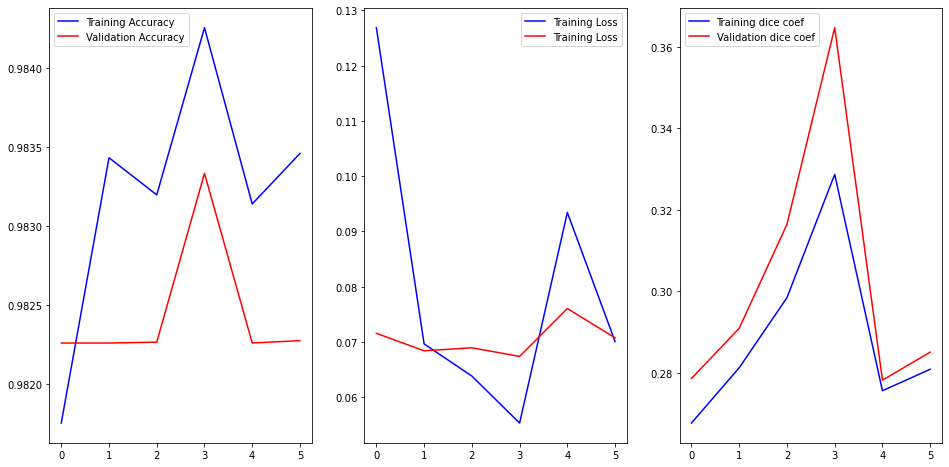

In [ ]:
hist=history.history

acc=hist['accuracy']
val_acc=hist['val_accuracy']

epoch=range(len(acc))

loss=hist['loss']
val_loss=hist['val_loss']

train_dice=hist['dice_coef']
val_dice=hist['val_dice_coef']

f,ax=plt.subplots(1,3,figsize=(16,8))

ax[0].plot(epoch,acc,'b',label='Training Accuracy')
ax[0].plot(epoch,val_acc,'r',label='Validation Accuracy')
ax[0].legend()

ax[1].plot(epoch,loss,'b',label='Training Loss')
ax[1].plot(epoch,val_loss,'r',label='Training Loss')
ax[1].legend()

ax[2].plot(epoch,train_dice,'b',label='Training dice coef')
ax[2].plot(epoch,val_dice,'r',label='Validation dice coef')
ax[2].legend()

plt.show()

In [ ]:
def vol_pred(case_path):
    flair = nib.load(glob.glob(os.path.join(case_path, '*_brain_t2f.nii.gz'))[0]).get_fdata()
    ce = nib.load(glob.glob(os.path.join(case_path, '*_brain_t1c.nii.gz'))[0]).get_fdata()

    X = np.empty((100, IMG_SIZE, IMG_SIZE, 2))
    for j in range(100):
         X[j,:,:,0] = cv2.resize(flair[:,:,j+22], (IMG_SIZE,IMG_SIZE))
         X[j,:,:,1] = cv2.resize(ce[:,:,j+22], (IMG_SIZE,IMG_SIZE))
    return model.predict(X/np.max(X), verbose=1)


path = test_ids[0]
gt = nib.load(glob.glob(os.path.join(path, '*_tumorMask.nii.gz'))[0]).get_fdata()
p = vol_pred(path)


core = p[:,:,:,1]
edema= p[:,:,:,2]
enhancing = p[:,:,:,3]


s = 50
plt.figure()
f, axarr = plt.subplots(1,5, figsize = (18, 50))

axarr[0].imshow(cv2.resize(gt[:,:,s+22], (IMG_SIZE, IMG_SIZE)), cmap="gray")
axarr[1].imshow(p[s,:,:,1:4], cmap="gray")
axarr[2].imshow(edema[s], cmap="gray")
axarr[3].imshow(core[s], cmap="gray")
axarr[4].imshow(enhancing[s], cmap="gray")

# Evaluation

In [ ]:
SEGMENT_CLASSES = {
    0 : 'NOT tumor',
    1 : 'NECROTIC/CORE', # or NON-ENHANCING tumor CORE
    2 : 'EDEMA',
    3 : 'ENHANCING' # original 4 -> converted into 3 later
}

# there are 155 slices per volume
# to start at 5 and use 145 slices means we will skip the first 5 and last 5 
VOLUME_SLICES = 100 
VOLUME_START_AT = 22 # first slice of volume that we will include

In [ ]:
def predictByPath(case_path):
    X = np.empty((VOLUME_SLICES, IMG_SIZE, IMG_SIZE, 2))

    flair = nib.load(glob.glob(os.path.join(case_path, '*_brain_t2f.nii.gz'))[0]).get_fdata()
    ce = nib.load(glob.glob(os.path.join(case_path, '*_brain_t1c.nii.gz'))[0]).get_fdata()

    for j in range(VOLUME_SLICES):
        X[j,:,:,0] = cv2.resize(flair[:,:,j+VOLUME_START_AT], (IMG_SIZE,IMG_SIZE))
        X[j,:,:,1] = cv2.resize(ce[:,:,j+VOLUME_START_AT], (IMG_SIZE,IMG_SIZE))

    return model.predict(X/np.max(X), verbose=1)


def showPredictsById(case_path, start_slice = 60):
    gt = nib.load(glob.glob(os.path.join(case_path, '*_tumorMask.nii.gz'))[0]).get_fdata()
    origImage = nib.load(glob.glob(os.path.join(case_path, '*_brain_t2f.nii.gz'))[0]).get_fdata()
    p = predictByPath(case_path)

    core = p[:,:,:,1]
    edema= p[:,:,:,2]
    enhancing = p[:,:,:,3]

    plt.figure(figsize=(18, 50))
    f, axarr = plt.subplots(1,6, figsize = (18, 50))

    for i in range(6): # for each image, add brain background
        axarr[i].imshow(cv2.resize(origImage[:,:,start_slice+VOLUME_START_AT], (IMG_SIZE, IMG_SIZE)), cmap="gray", interpolation='none')

    axarr[0].imshow(cv2.resize(origImage[:,:,start_slice+VOLUME_START_AT], (IMG_SIZE, IMG_SIZE)), cmap="gray")
    axarr[0].title.set_text('Original image flair')
    curr_gt=cv2.resize(gt[:,:,start_slice+VOLUME_START_AT], (IMG_SIZE, IMG_SIZE), interpolation = cv2.INTER_NEAREST)
    axarr[1].imshow(curr_gt, cmap="Reds", interpolation='none', alpha=0.3) # ,alpha=0.3,cmap='Reds'
    axarr[1].title.set_text('Ground truth')
    axarr[2].imshow(p[start_slice,:,:,1:4], cmap="Reds", interpolation='none', alpha=0.3)
    axarr[2].title.set_text('all classes')
    axarr[3].imshow(edema[start_slice,:,:], cmap="OrRd", interpolation='none', alpha=0.3)
    axarr[3].title.set_text(f'{SEGMENT_CLASSES[1]} predicted')
    axarr[4].imshow(core[start_slice,:,], cmap="OrRd", interpolation='none', alpha=0.3)
    axarr[4].title.set_text(f'{SEGMENT_CLASSES[2]} predicted')
    axarr[5].imshow(enhancing[start_slice,:,], cmap="OrRd", interpolation='none', alpha=0.3)
    axarr[5].title.set_text(f'{SEGMENT_CLASSES[3]} predicted')
    plt.show()


showPredictsById(test_ids[0])
showPredictsById(test_ids[1])
showPredictsById(test_ids[2])
showPredictsById(test_ids[3])
showPredictsById(test_ids[4])
showPredictsById(test_ids[5])
showPredictsById(test_ids[6])

In [ ]:
path = test_ids[3]
gt = nib.load(glob.glob(os.path.join(path, '*_tumorMask.nii.gz'))[0]).get_fdata()
p = predictByPath(path)

core = p[:,:,:,1]
edema= p[:,:,:,2]
enhancing = p[:,:,:,3]


i=40 # slice at
eval_class = 2 #     0 : 'NOT tumor',  1 : 'ENHANCING',    2 : 'CORE',    3 : 'WHOLE'



gt[gt != eval_class] = 1 # use only one class for per class evaluation

resized_gt = cv2.resize(gt[:,:,i+VOLUME_START_AT], (IMG_SIZE, IMG_SIZE))

plt.figure()
f, axarr = plt.subplots(1,2)
axarr[0].imshow(resized_gt, cmap="gray")
axarr[0].title.set_text('ground truth')
axarr[1].imshow(p[i,:,:,eval_class], cmap="gray")
axarr[1].title.set_text(f'predicted class: {SEGMENT_CLASSES[eval_class]}')
plt.show()

In [ ]:
# NOTE: using OneHotMeanIoU, not MeanIoU -- the model outputs softmax
# probabilities (not exact one-hot vectors), and plain MeanIoU silently
# computes the wrong number against continuous probability outputs
# (verified: it reports ~0.375 mean IoU even for a perfectly-correct
# prediction). OneHotMeanIoU is the metric actually meant for this case.
model.compile(loss="categorical_crossentropy", optimizer=keras.optimizers.Adam(learning_rate=0.001), metrics = ['accuracy',tf.keras.metrics.OneHotMeanIoU(num_classes=4), dice_coef, precision, sensitivity, specificity, dice_coef_necrotic, dice_coef_edema, dice_coef_enhancing] )
# Evaluate the model on the test data using `evaluate`
print("Evaluate on test data")
results = model.evaluate(test_generator, batch_size=100, callbacks= callbacks)
print("test loss, test acc:", results)
